# Đánh giá, so sánh và trực quan hóa

Nguyễn Ngọc Hoàng Nam — B23DCCN585 | ASG 06

Các cell nhỏ được sắp theo thứ tự phụ thuộc. Huấn luyện đầy đủ mặc định tắt; số liệu chạy thử không phải kết quả test chính thức.

In [1]:
from pathlib import Path
import sys, json, os
ROOT=Path.cwd().resolve()
if ROOT.name=="notebooks": ROOT=ROOT.parent
assert (ROOT/"src").is_dir()
if str(ROOT) not in sys.path: sys.path.insert(0,str(ROOT))
from src.paths import DATA
from src.io import read_json
import numpy as np
import pandas as pd
from IPython.display import display, Image
print("Project:", ROOT)
print("Data:", DATA)


Project: E:\PTHTTM\ASG_06
Data: E:\PTHTTM\ASG_06_data


Chỉ kết quả trong results/runs được dùng cho báo cáo chính. Smoke được lưu riêng. Các đối chứng được fit trên train.

In [2]:
records=[]
for folder in sorted((ROOT/'results/runs').glob('*')):
    if (folder/'metrics.json').exists(): records.append(read_json(folder/'metrics.json'))
if records: display(pd.DataFrame(records))
else: print('Chưa có kết quả huấn luyện đầy đủ.')

,accuracy,macro_f1,log_loss,per_class,ap_1,ap_2,confusion_matrix,dataset,framework,seed,...,smoke,evaluation_split,mae,rmse,directional_accuracy,mean_true_return,mean_predicted_return,price_mae,price_rmse,price_reconstruction_clipped
0,0.901059,0.581783,0.340711,"[{'label': 0, 'precision': 0.9478138222849083,...",0.274927,0.459440,"[[102816, 2907, 2488], [5257, 2087, 339], [404...",retailrocket,keras,42,...,False,test,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.900924,0.582107,0.340692,"[{'label': 0, 'precision': 0.9478454913460032,...",0.275497,0.460469,"[[102791, 2947, 2473], [5248, 2101, 334], [408...",retailrocket,pytorch,42,...,False,test,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,sp500,keras,42,...,False,test,0.010012,0.015533,0.501668,0.000397,0.000785,0.981076,2.413375,0.0
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,sp500,pytorch,42,...,False,test,0.010012,0.015533,0.501710,0.000397,0.000785,0.981075,2.413370,0.0


In [3]:
path=ROOT/'results/baselines.json'
if path.exists(): display(pd.DataFrame(read_json(path)))

,accuracy,macro_f1,log_loss,per_class,ap_1,ap_2,confusion_matrix,dataset,model,mae,rmse,directional_accuracy,mean_true_return,mean_predicted_return,price_mae,price_rmse,price_reconstruction_clipped
0,0.915553,0.318638,0.335413,"[{'label': 0, 'precision': 0.9155526600785163,...",0.065004,0.019443,"[[108211, 0, 0], [7683, 0, 0], [2298, 0, 0]]",retailrocket,prior,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.915553,0.318638,0.288966,"[{'label': 0, 'precision': 0.9155526600785163,...",0.105927,0.178815,"[[108211, 0, 0], [7683, 0, 0], [2298, 0, 0]]",retailrocket,markov,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,sp500,zero_return,0.009756,0.015297,0.008252,0.000397,0.000000,0.957937,2.388390,0.0
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,sp500,train_mean_return,0.009736,0.015291,0.530929,0.000397,0.000408,0.955596,2.387203,0.0


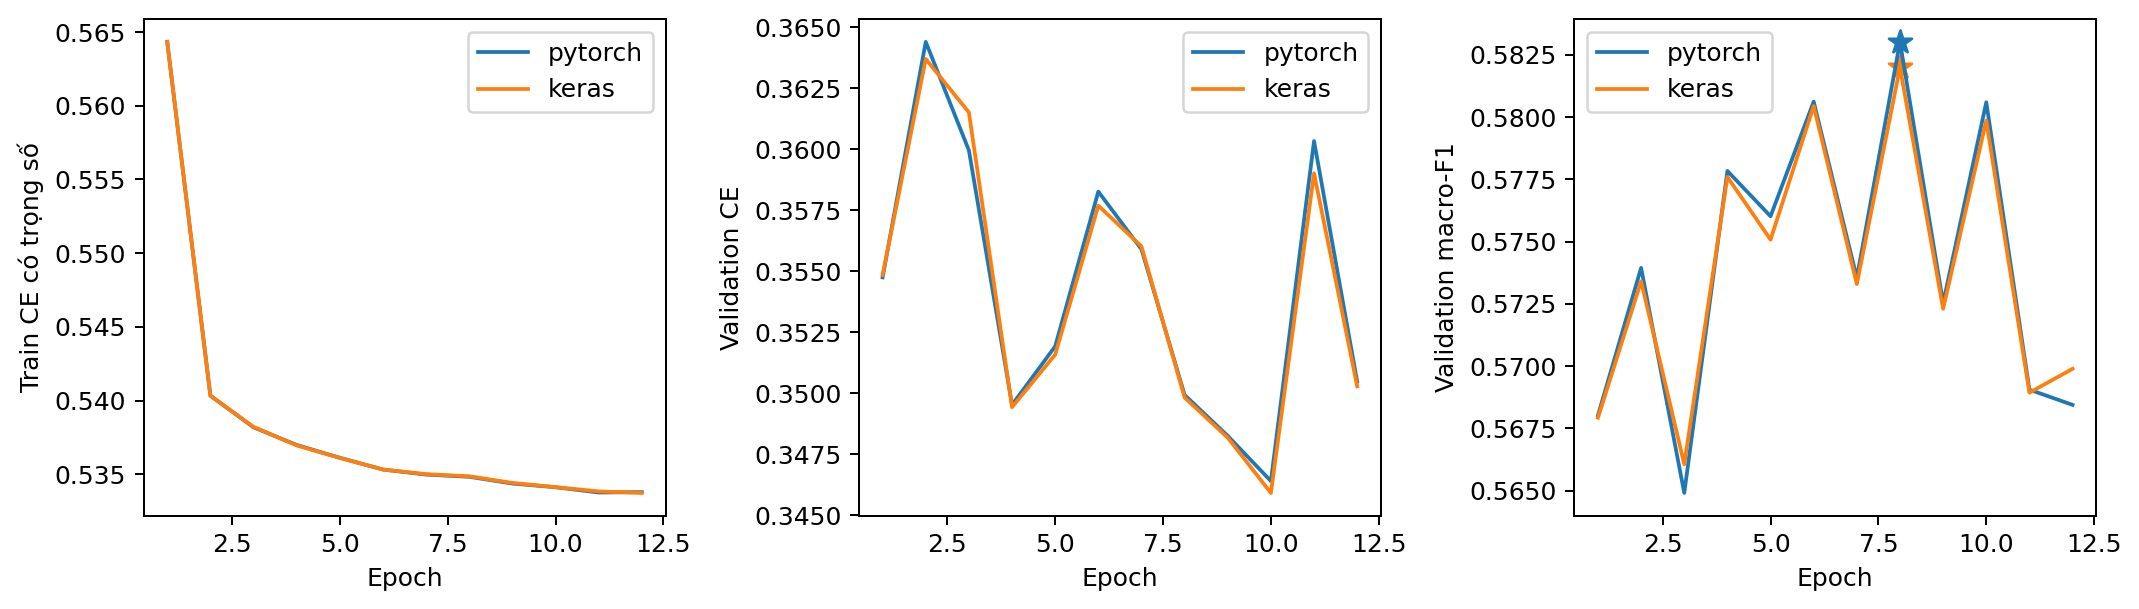

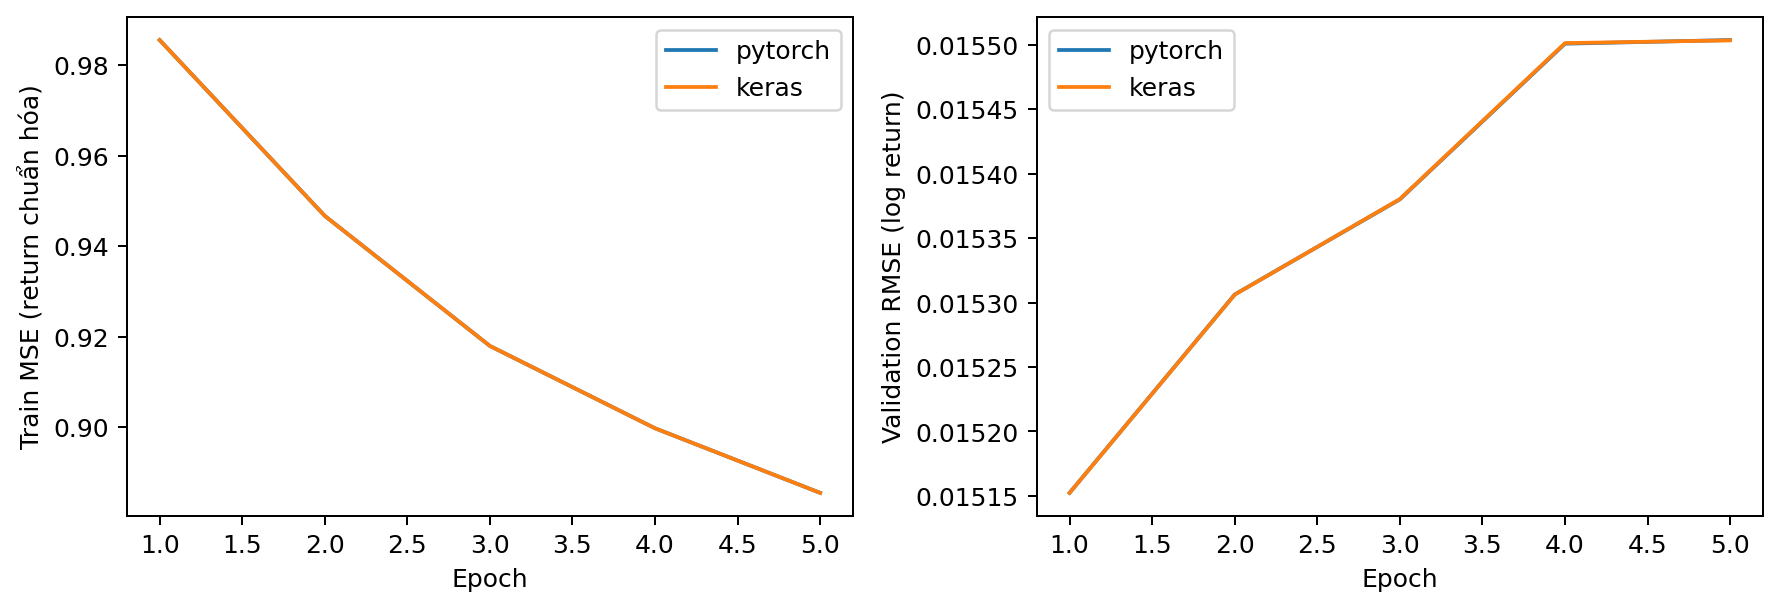

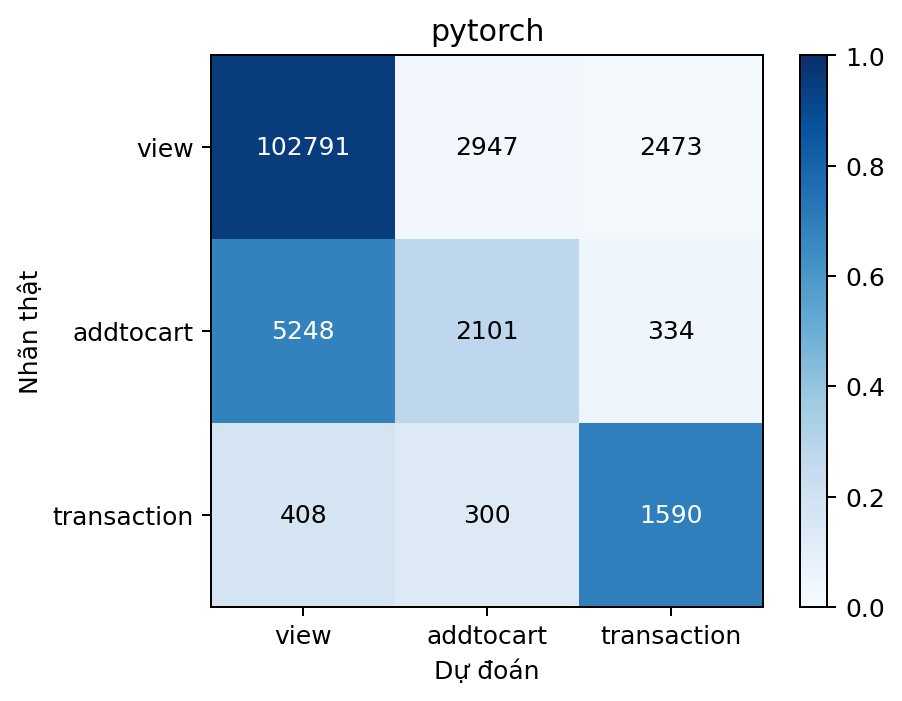

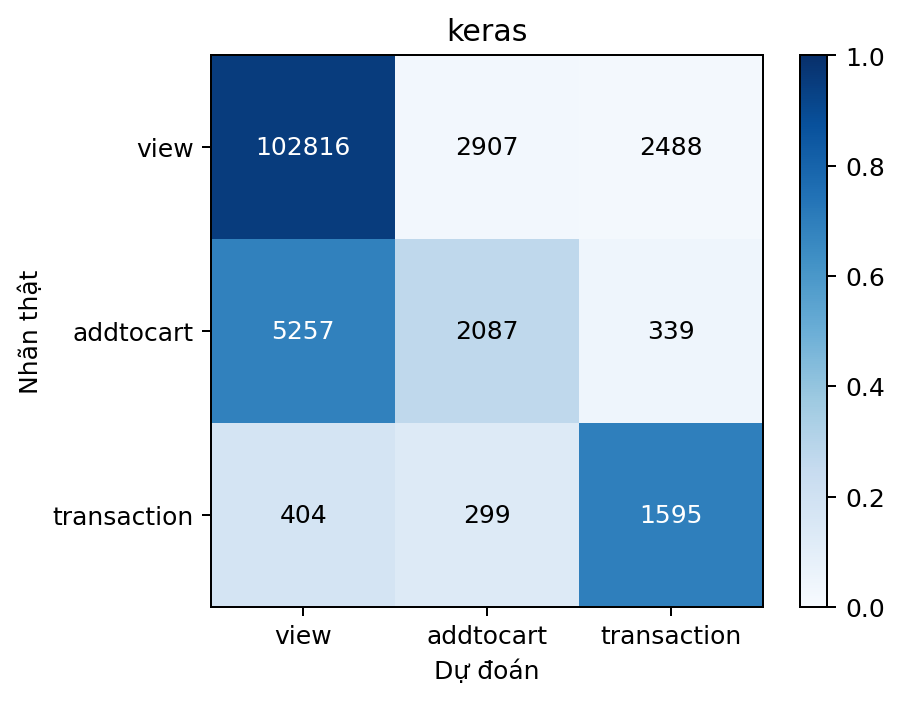

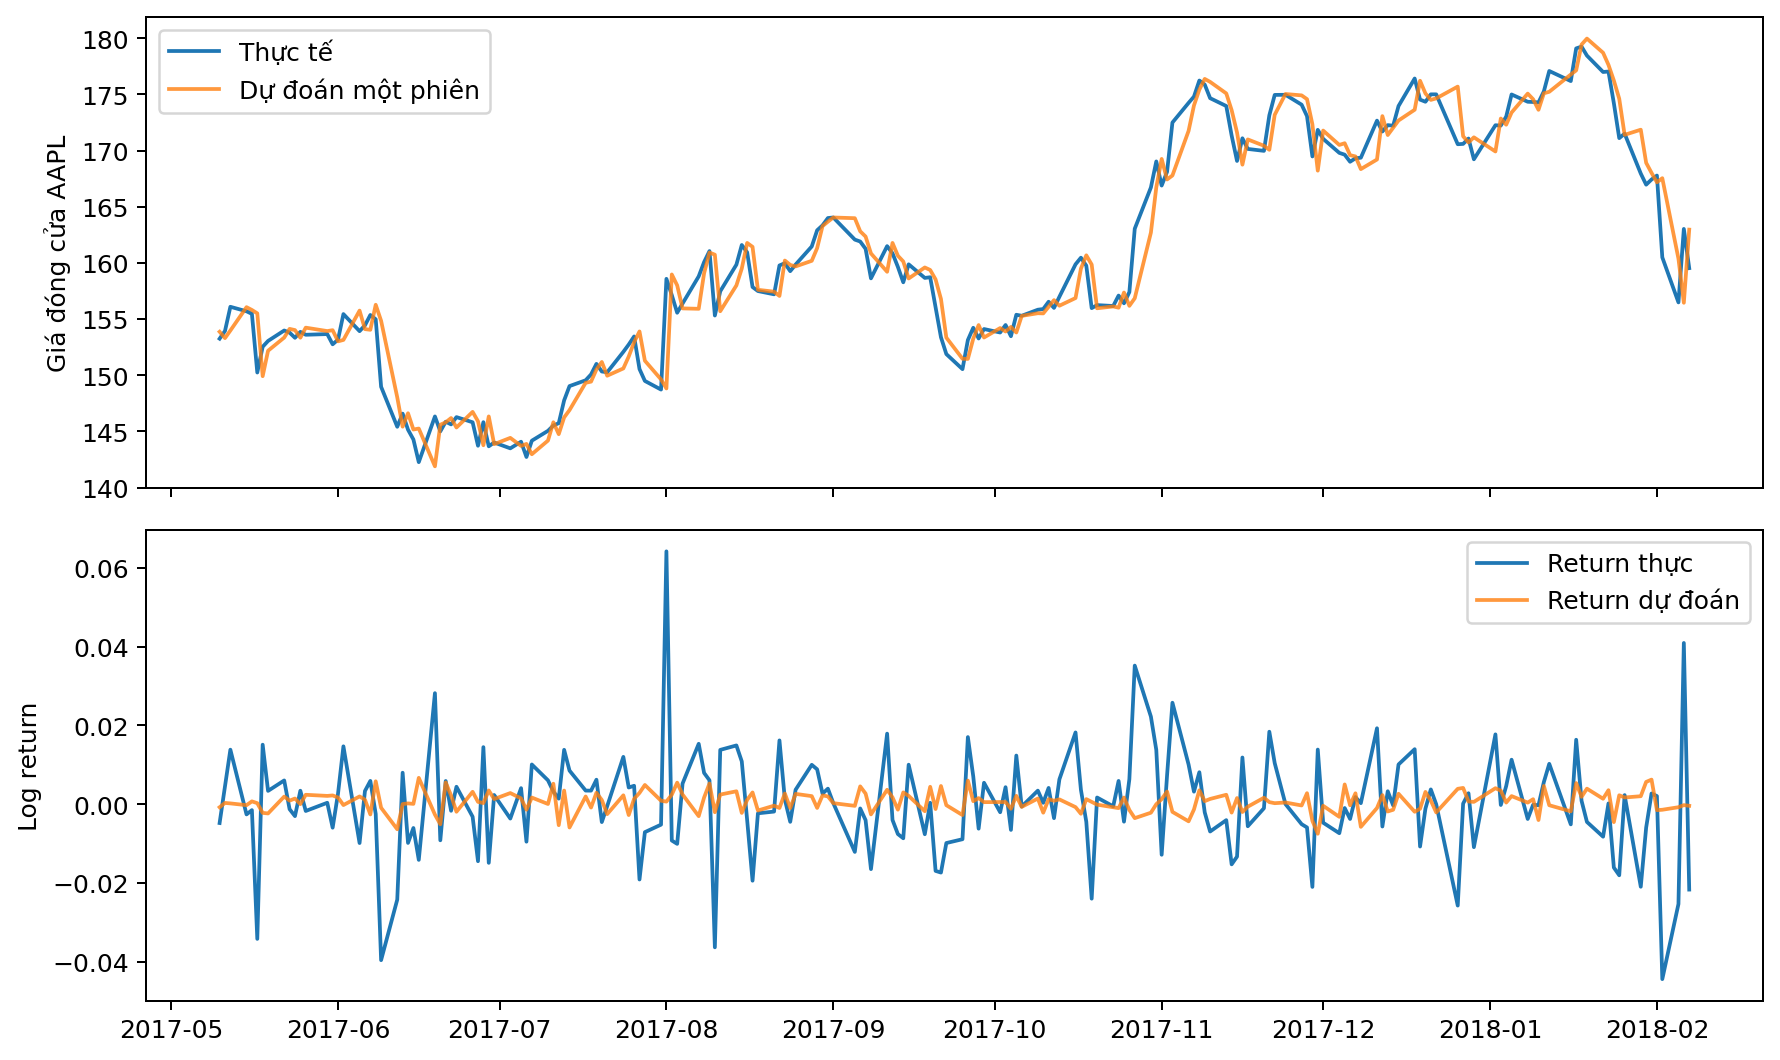

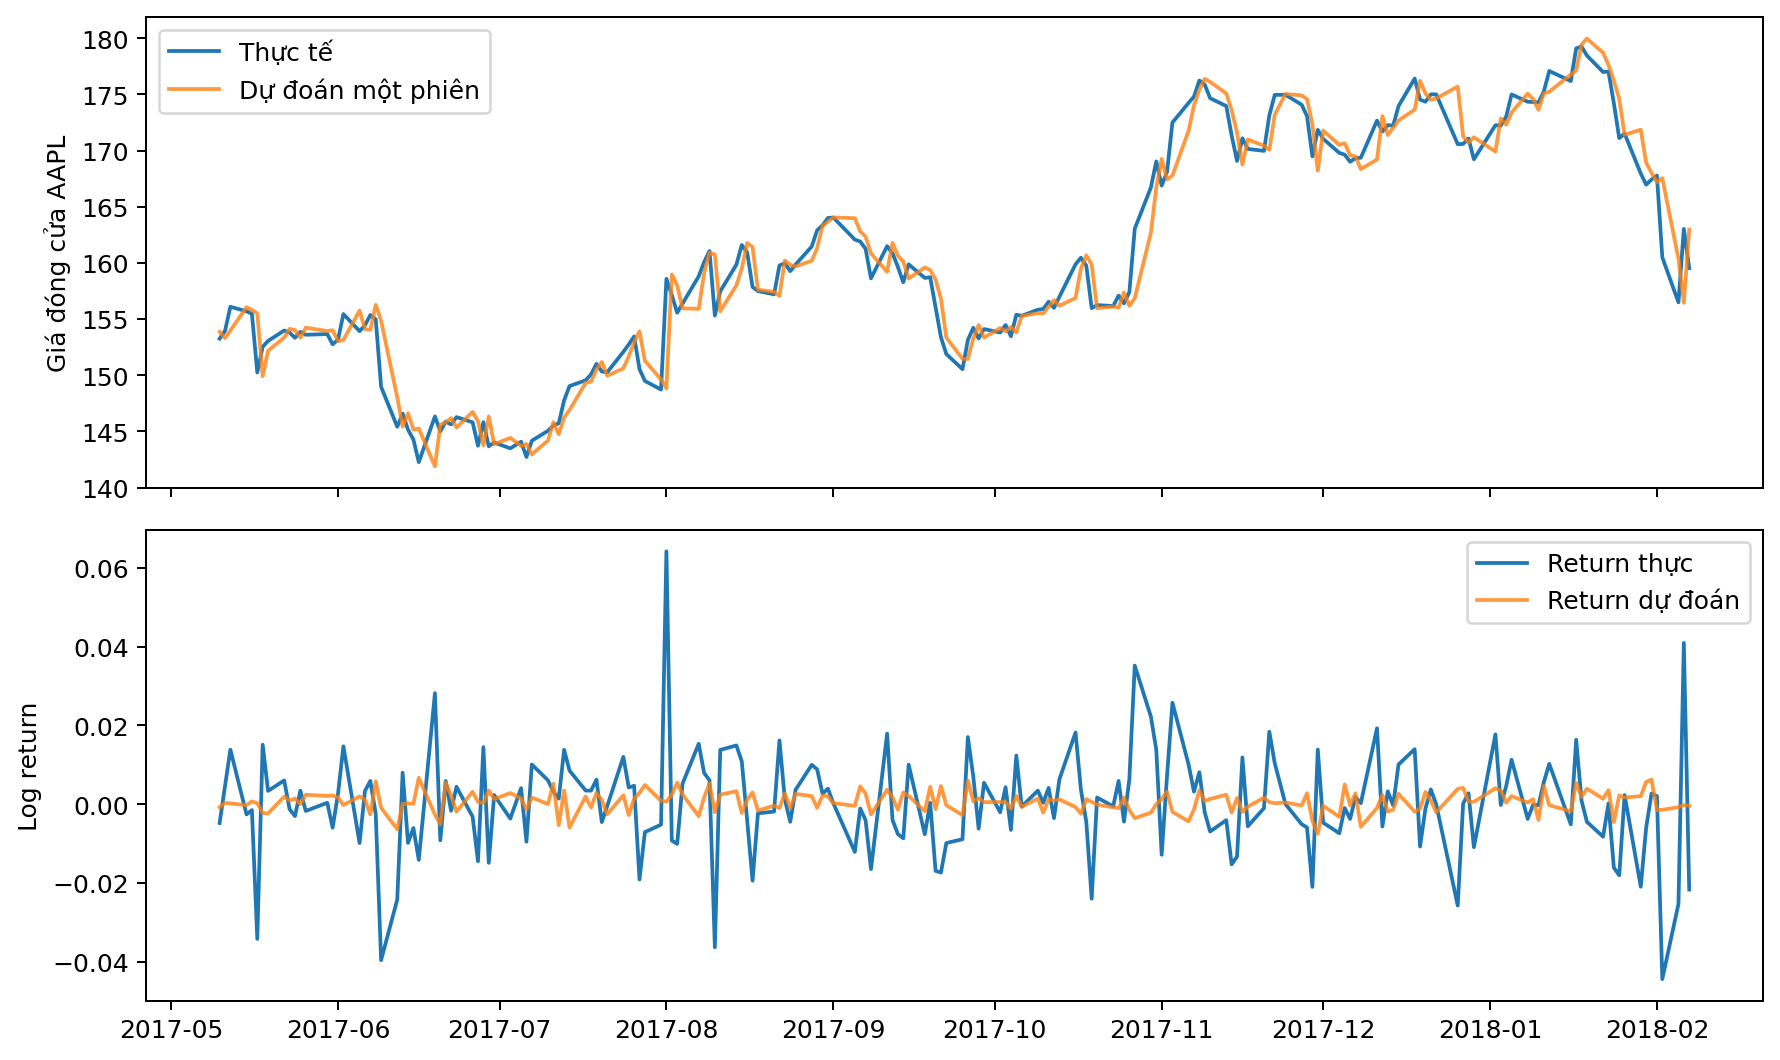

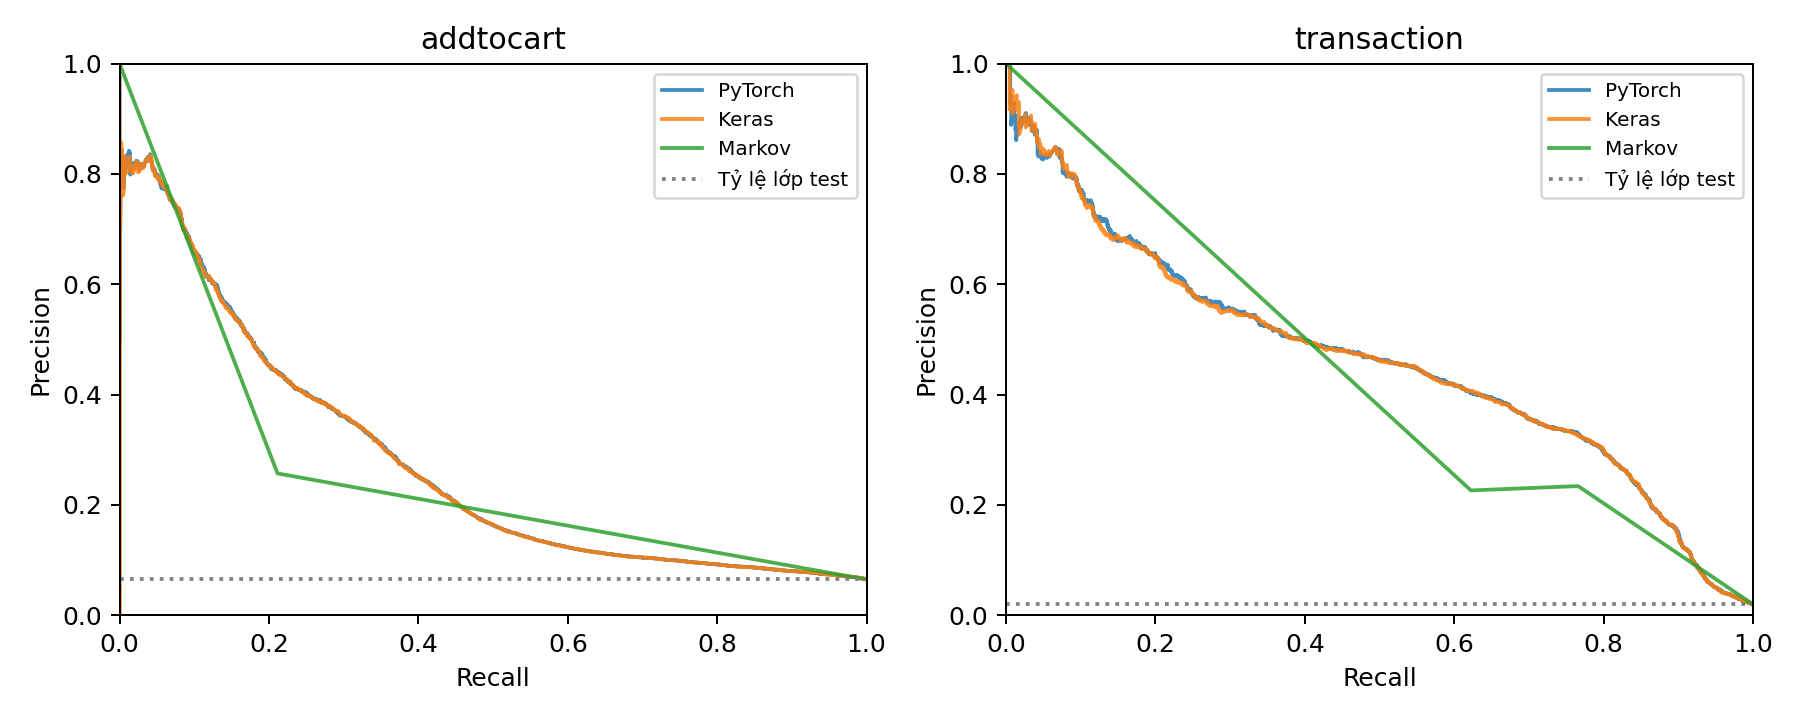

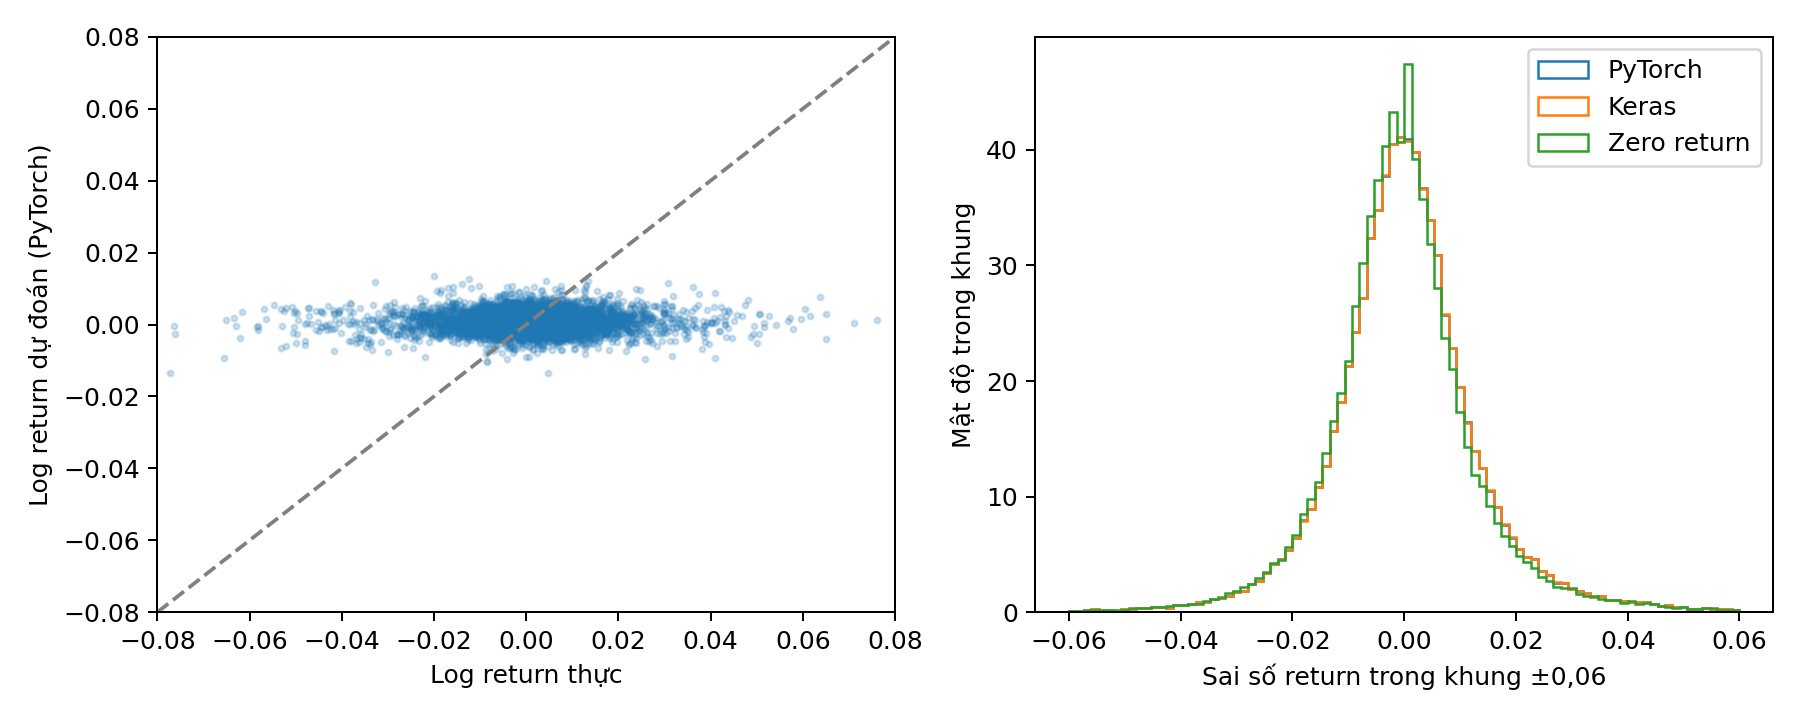

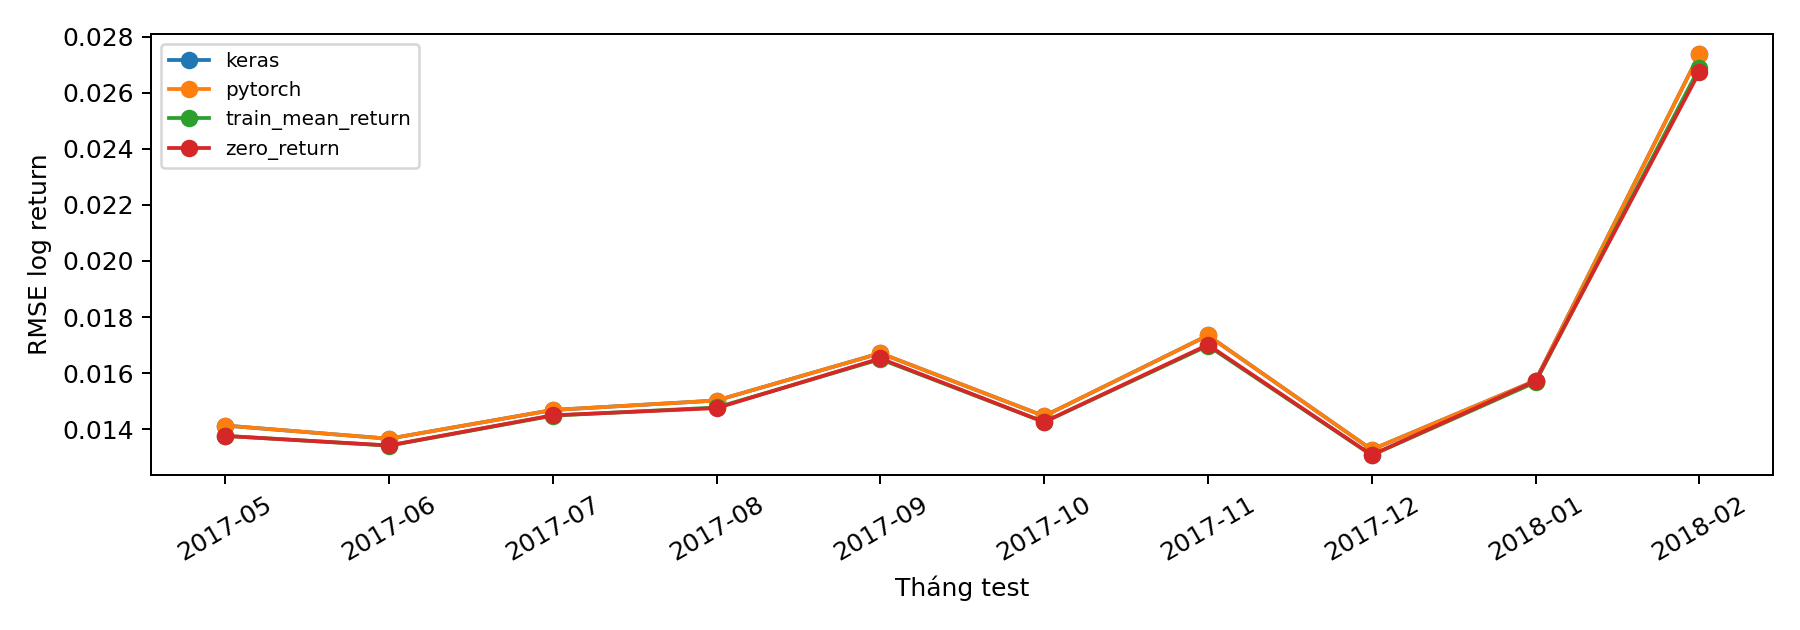

In [4]:
for name in ['retailrocket_learning','sp500_learning','retailrocket_pytorch_confusion','retailrocket_keras_confusion','sp500_pytorch_forecast','sp500_keras_forecast','retail_pr','stock_diagnostics','stock_monthly']:
    path=ROOT/'figures'/(name+'.png')
    if path.exists(): display(Image(filename=str(path)))

In [5]:
path=ROOT/'results/paired_framework_analysis.json'
if path.exists(): display(read_json(path))

{'retailrocket': {'max_probability_difference': 0.23988628387451172,
  'mean_probability_difference': 0.001638455898500979,
  'prediction_agreement': 0.9982993772844185},
 'sp500': {'max_return_difference': 1.5996629372239113e-05,
  'mean_return_difference': 2.5923714019882027e-06,
  'actual_return_std': 0.015291494317352772,
  'pytorch_return_std': 0.002689426764845848,
  'keras_return_std': 0.0026895918417721987,
  'upward_share': 0.5309292999463198,
  'downward_share': 0.46081867651857233,
  'zero_share': 0.00825202353510794}}

Kết quả thực nghiệm: macro-F1 Retailrocket xấp xỉ 0,582, cao hơn đối chứng argmax luôn-view; accuracy và log loss không vượt mọi đối chứng. RNN cổ phiếu có RMSE khoảng 0,015533, cao hơn đối chứng trung bình train 0,015291. Cả hai framework chọn epoch 8 cho Retailrocket và epoch 1 cho S&P 500.

Retailrocket: macro-F1 và từng lớp bổ sung accuracy trong tình huống mất cân bằng. Chứng khoán: so sánh sai số log return với dự đoán zero-return; giá dự báo sát giá thực không tự chứng minh có giá trị vượt đối chứng.